# Demonstration of PartitionedAccessor and Polars to Retrieve PSD Data

## imports

Feb. 10, 2026 - use the partitioned-file-accessor branch of orcasound_noise for use of PartitionedAccessor

```python
orcasound_noise@git+https://github.com/orcasound/ambient-sound-analysis@partitioned-file-accessor
```

In [3]:
import polars as pl
import datetime as dt
import matplotlib.pyplot as plt

In [13]:
import orcasound_noise.pipeline.acoustic_util as acoustic_util
from orcasound_noise.analysis.partitioned_accessor import PartitionedAccessor
from orcasound_noise.utils import Hydrophone

## Example using polars

Lazy load PSD and broadband dataframe using scan_parquet, polars loads all parquet files into one dataframe

In [4]:
psd_df = pl.scan_parquet('s3://acoustic-sandbox/ambient-sound-analysis/data_2.0/psd/', storage_options={'aws_region': 'us-west-2'})
bb_df = pl.scan_parquet('s3://acoustic-sandbox/ambient-sound-analysis/data_2.0/broadband/', storage_options={'aws_region': 'us-west-2'})

Query time range. Using year, month, day to utilize partitions for faster load

In [5]:
query = psd_df.filter(
    (pl.col('year') == 2026) &
    (pl.col('month') == 2) &
    (pl.col('day') == 9) &
    (pl.col('__index_level_0__') >= dt.datetime(2026, 2, 9, 0, 0, 0)) &
    (pl.col('__index_level_0__') <= dt.datetime(2026, 2, 9, 12, 0, 0)) &
    (pl.col('hydrophone') == 'port_townsend')
)

.collect() loads the actual data

In [7]:
query.collect().head()

67,71,75,80,85,90,95,100,106,112,118,125,132,140,150,160,170,180,190,200,212,224,236,250,265,280,300,315,335,355,375,400,425,450,475,500,530,…,3750,4000,4250,4500,4750,5000,5300,5600,6000,6300,6700,7100,7500,8000,8500,9000,9500,10000,10600,11200,11800,12500,13200,14000,15000,16000,17000,18000,19000,20000,21200,22400,__index_level_0__,hydrophone,year,month,day
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[ns],str,i64,i64,i64
23.55073,23.795419,25.167956,26.717178,27.564323,28.106927,28.559454,28.805584,27.535188,26.094118,25.751556,25.738107,24.568007,26.518519,25.172746,25.153571,25.643376,25.023027,25.928916,26.868172,25.607014,25.946454,25.656972,25.822935,26.192603,25.404257,26.563513,24.573139,25.64791,25.994503,26.431969,25.129544,26.063921,25.898138,26.664914,26.037954,26.70113,…,27.951849,27.934446,27.87852,27.832814,28.513944,28.697762,28.494367,28.649765,28.630492,28.678595,28.636921,28.627275,28.720071,28.896504,28.792969,29.202916,29.217957,29.190865,29.099944,29.18785,29.220962,29.014218,29.038797,28.70733,27.204292,27.192916,27.428746,15.387547,5.575072,6.361267,4.454329,4.402162,2026-02-09 11:41:47,"""port_townsend""",2026,2,9
20.953284,22.822722,22.993618,21.598089,23.671091,23.795419,23.331562,24.217067,24.524262,24.608978,26.239313,26.563513,26.083345,26.022771,25.490084,25.697634,26.628546,26.289985,26.39669,26.958304,25.686358,26.592025,25.677327,26.355001,26.081189,26.122064,27.037858,26.735197,26.504154,26.534908,26.743193,26.485649,26.409157,26.592025,27.11669,26.3717,26.997202,…,28.564316,28.811885,28.715295,28.604727,29.060248,29.343279,29.077065,29.250955,29.29724,29.29575,29.29724,29.264418,29.253948,29.349202,29.41115,29.697381,29.577099,29.807598,29.858,29.959315,29.771014,29.628853,29.40968,29.310631,28.176666,28.158011,28.291111,18.501082,-8.290785,-3.741733,-8.068058,-14.199308,2026-02-09 11:41:48,"""port_townsend""",2026,2,9
23.094564,22.238686,22.427914,23.699504,22.866543,22.616321,23.143089,23.378784,23.608253,24.601311,26.167019,26.745191,25.713396,25.249022,25.643376,25.876087,26.405003,26.409157,26.648769,26.705145,26.327795,26.111326,26.367528,26.658863,26.473291,26.495934,26.650789,26.252009,26.685053,26.398769,26.800946,26.260462,26.323602,26.402926,27.152981,26.834624,27.008837,…,28.347773,28.766099,28.476382,28.539979,28.90897,29.104513,28.924528,29.159151,28.981851,29.069425,29.190865,29.172757,29.116685,29.13946,29.340316,29.671746,29.490153,29.71159,29.806194,29.839833,29.684573,29.70875,29.304682,29.177288,28.015939,28.086409,28.079559,17.94154,-6.650941,-4.152166,-6.93575,-18.786043,2026-02-09 11:41:49,"""port_townsend""",2026,2,9
22.869664,22.693103,22.97822,22.414768,23.414033,23.662549,23.191344,23.770133,24.344413,24.39431,26.083345,26.620443,26.213866,25.656972,25.87167,26.34873,26.096271,25.994503,26.268907,26.279452,26.243547,26.361267,26.147781,26.311011,26.559432,26.460915,26.699122,26.014083,26.079033,26.323602,26.771122,26.336175,26.380038,26.699122,26.979719,26.995261,26.689075,…,28.517203,28.652973,28.404067,28.456719,28.704142,28.944712,28.696167,29.014218,28.873081,29.031124,29.067896,29.066367,29.000361,29.018832,29.175778,29.490153,29.415558,29.519232,29.478494,29.724358,29.748424,29.668893,29.074009,29.012679,27.918753,28.081272,28.127397,17.830749,-7.230215,-4.222498,-8.519375,-11.700533,2026-02-09 11:41:50,"""port_townsend""",2026,2,9
23.989618,23.671091,24.920118,24.863242,25.324634,25.095794,24.443921,24.37596,25.305793,25.441476,26.703138,26.19686,25.387924,26.113475,26.814829,27.185323,26.956354,27.141537,27.164409,27.320984,26.268907,26.932926,27.27224,26.901591,26.870141,27.118604,27.170118,27.114776,27.507785,27.204292,26.983607,26.893739,27.547947,27.332194,27.772679,27.932703,27.502294,…,28.27605,28.660988,28.34777

query for quantile plot

In [11]:
quant_df = bb_df.with_columns(
    (pl.col("0")
       .rank(method="average")
       / pl.len()
    ).alias("quantile")
).filter(pl.col("0") > 0).select(["0", "quantile"])

In [12]:
quant_df = quant_df.collect()

Text(0, 0.5, 'Quantile')

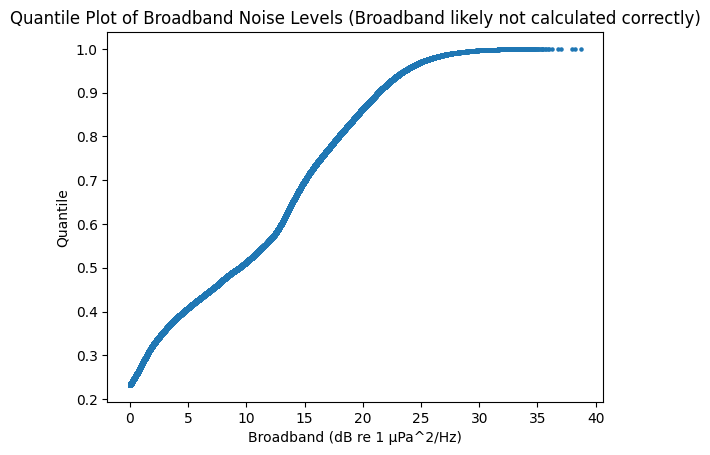

In [29]:
plt.scatter(quant_df["0"], quant_df["quantile"], s=5)
plt.title("Quantile Plot of Broadband Noise Levels (Broadband likely not calculated correctly)")
plt.xlabel("Broadband (dB re 1 μPa^2/Hz)")
plt.ylabel("Quantile")

## Example using PartitionedAccessor

In [14]:
pa = PartitionedAccessor(Hydrophone.PORT_TOWNSEND)

In [16]:
psd_df = pa.get_time_range(dt.datetime(2026, 2, 9, 0, 0, 0), dt.datetime(2026, 2, 9, 12, 0, 0), psd=True)
psd_df.head()

67,71,75,80,85,90,95,100,106,112,118,125,132,140,150,160,170,180,190,200,212,224,236,250,265,280,300,315,335,355,375,400,425,450,475,500,530,…,3550,3750,4000,4250,4500,4750,5000,5300,5600,6000,6300,6700,7100,7500,8000,8500,9000,9500,10000,10600,11200,11800,12500,13200,14000,15000,16000,17000,18000,19000,20000,21200,22400,__index_level_0__,year,month,day
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[ns],i64,i64,i64
23.55073,23.795419,25.167956,26.717178,27.564323,28.106927,28.559454,28.805584,27.535188,26.094118,25.751556,25.738107,24.568007,26.518519,25.172746,25.153571,25.643376,25.023027,25.928916,26.868172,25.607014,25.946454,25.656972,25.822935,26.192603,25.404257,26.563513,24.573139,25.64791,25.994503,26.431969,25.129544,26.063921,25.898138,26.664914,26.037954,26.70113,…,27.719271,27.951849,27.934446,27.87852,27.832814,28.513944,28.697762,28.494367,28.649765,28.630492,28.678595,28.636921,28.627275,28.720071,28.896504,28.792969,29.202916,29.217957,29.190865,29.099944,29.18785,29.220962,29.014218,29.038797,28.70733,27.204292,27.192916,27.428746,15.387547,5.575072,6.361267,4.454329,4.402162,2026-02-09 11:41:47,2026,2,9
20.953284,22.822722,22.993618,21.598089,23.671091,23.795419,23.331562,24.217067,24.524262,24.608978,26.239313,26.563513,26.083345,26.022771,25.490084,25.697634,26.628546,26.289985,26.39669,26.958304,25.686358,26.592025,25.677327,26.355001,26.081189,26.122064,27.037858,26.735197,26.504154,26.534908,26.743193,26.485649,26.409157,26.592025,27.11669,26.3717,26.997202,…,28.415612,28.564316,28.811885,28.715295,28.604727,29.060248,29.343279,29.077065,29.250955,29.29724,29.29575,29.29724,29.264418,29.253948,29.349202,29.41115,29.697381,29.577099,29.807598,29.858,29.959315,29.771014,29.628853,29.40968,29.310631,28.176666,28.158011,28.291111,18.501082,-8.290785,-3.741733,-8.068058,-14.199308,2026-02-09 11:41:48,2026,2,9
23.094564,22.238686,22.427914,23.699504,22.866543,22.616321,23.143089,23.378784,23.608253,24.601311,26.167019,26.745191,25.713396,25.249022,25.643376,25.876087,26.405003,26.409157,26.648769,26.705145,26.327795,26.111326,26.367528,26.658863,26.473291,26.495934,26.650789,26.252009,26.685053,26.398769,26.800946,26.260462,26.323602,26.402926,27.152981,26.834624,27.008837,…,28.347773,28.347773,28.766099,28.476382,28.539979,28.90897,29.104513,28.924528,29.159151,28.981851,29.069425,29.190865,29.172757,29.116685,29.13946,29.340316,29.671746,29.490153,29.71159,29.806194,29.839833,29.684573,29.70875,29.304682,29.177288,28.015939,28.086409,28.079559,17.94154,-6.650941,-4.152166,-6.93575,-18.786043,2026-02-09 11:41:49,2026,2,9
22.869664,22.693103,22.97822,22.414768,23.414033,23.662549,23.191344,23.770133,24.344413,24.39431,26.083345,26.620443,26.213866,25.656972,25.87167,26.34873,26.096271,25.994503,26.268907,26.279452,26.243547,26.361267,26.147781,26.311011,26.559432,26.460915,26.699122,26.014083,26.079033,26.323602,26.771122,26.336175,26.380038,26.699122,26.979719,26.995261,26.689075,…,28.244169,28.517203,28.652973,28.404067,28.456719,28.704142,28.944712,28.696167,29.014218,28.873081,29.031124,29.067896,29.066367,29.000361,29.018832,29.175778,29.490153,29.415558,29.519232,29.478494,29.724358,29.748424,29.668893,29.074009,29.012679,27.918753,28.081272,28.127397,17.830749,-7.230215,-4.222498,-8.519375,-11.700533,2026-02-09 11:41:50,2026,2,9
23.989618,23.671091,24.920118,24.863242,25.324634,25.095794,24.443921,24.37596,25.305793,25.441476,26.703138,26.19686,25.387924,26.113475,26.814829,27.185323,26.956354,27.141537,27.164409,27.320984,26.268907,26.932926,27.27224,26.901591,26.870141,27.118604,27.170118,27.114776,27.507785,27.204292,26.983607,26.893739,27.547947,27.332194,27.772679,27.932703,27.502294,…,28.316155,28.27605,28.660988,28.347773,28.544852,28.668996,28.747083,28.6